<a href="https://colab.research.google.com/github/skguskim/Agent-AI/blob/main/04_%EB%B6%80%EB%A1%9D_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

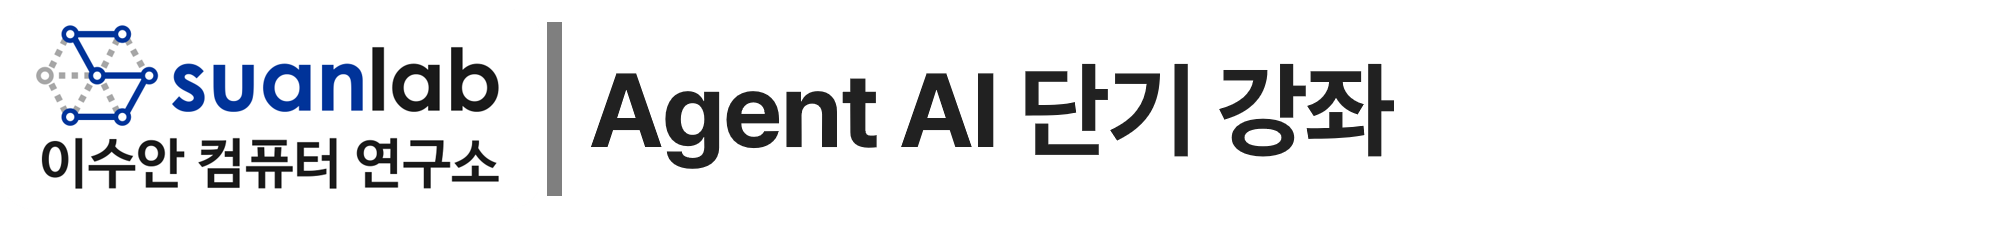

# 🧪 부록 실습 — Claude 심화 기법

- 본 강좌를 빨리 끝낸 분, 또는 **복습·심화 트랙**
- 세션 1~3과 **독립적으로** 위에서 아래로 실행

## 다루는 것 (각 파트 독립)
| 순서 | 주제 | 한 줄 요약 |
|------|------|-----------|
| 1 | **Prompt Caching** | 반복되는 긴 컨텍스트의 입력 비용을 캐시로 절감 |
| 2 | **Streaming** | 토큰이 생성되는 즉시 출력(체감 지연↓·UX↑) |
| 3 | **구조화 출력** | Tool Use로 **항상 정해진 JSON 스키마**를 강제 |
| 4 | **Eval(LLM-as-a-judge)** | 에이전트/프롬프트 품질을 **점수**로 객관화 |
| 5 | **최신 모델 관례** | adaptive thinking · effort(선택 옵션) 소개 |
| 6 | **에러 핸들링 & 비용/토큰 관리** | 예외 분류표 · 재시도 심화 · 현업 운영 팁 |
| 7 | **종합 미니 프로젝트 + 복습 퀴즈** | 캐싱+구조화+Eval을 한 흐름으로 결합 |

## 이 부록을 읽는 법
- 각 파트는 **개념(마크다운) → 데모(코드) → 주의(⚠️) → 미니 실습(TODO+정답)** 순서로 반복
- 코드 셀 위의 마크다운은 "**왜 이렇게 쓰는가**"를 설명
- 막히면 각 파트의 **자주하는 실수** 표와 **더 알아보기**(공식 문서 안내)를 보기

> 각 파트는 앞 파트 없이도 단독 실행 가능(0번 환경 셀만 먼저 실행)

## 환경 준비
- Colab은 세션마다 패키지를 새로 설치해야 함
- 이 부록은 표준 라이브러리와 `anthropic`만 사용 (langgraph 등 추가 설치 불필요 — 독립 실행)

In [ ]:
!pip install -q anthropic

### API Key 안전하게 불러오기
키를 코드에 직접 쓰면 노트북 공유 시 **유출**됩니다. Colab 왼쪽 🔑(Secrets)에 `ANTHROPIC_API_KEY`를 등록하세요.

In [ ]:
import os
# 키 로딩 순서: ① Colab Secrets(userdata) 우선 → ② 실패하면 getpass 입력 폴백.
# Colab이 아닌 로컬 환경이나 Secrets 미등록 시 import/get이 실패하므로 except로 안전하게 폴백한다.
# 키를 코드 셀에 하드코딩하면 노트북 공유 시 유출되니 절대 금지.
try:
    from google.colab import userdata
    os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
    print(' Colab Secrets에서 키 로딩 완료')
except Exception:
    # 폴백: 화면에 노출되지 않게 getpass로 입력받는다(키 누락 시 친절 안내).
    from getpass import getpass
    os.environ['ANTHROPIC_API_KEY'] = getpass('ANTHROPIC_API_KEY를 입력하세요(왼쪽 🔑 Secrets 등록을 권장): ')
    print(' 입력값으로 키 설정 완료')

ANTHROPIC_API_KEY를 입력하세요(왼쪽 🔑 Secrets 등록을 권장): ··········
 입력값으로 키 설정 완료


### 공용 상수·헬퍼 정의
**`MODEL` 상수 한 곳**에서 모델명을 관리하고, 단체 실습 안전장치인 `call_with_retry`와 XML 파싱용 `extract`를 미리 정의

In [ ]:
import json, time, re
import anthropic

client = anthropic.Anthropic()
MODEL = 'claude-sonnet-4-6'   # ★ 모델명은 이 한 곳에서만 관리(오타·교체 리스크 격리)

def call_with_retry(max_retries=4, **kwargs):
    '''일시적 오류(429/529/연결)에만 지수 백오프 재시도. 인증/형식 오류는 즉시 raise.'''
    for attempt in range(max_retries):
        try:
            return client.messages.create(**kwargs)
        except (anthropic.RateLimitError, anthropic.InternalServerError, anthropic.APIConnectionError) as e:
            wait = 2 ** attempt   # 1, 2, 4, 8초로 점점 길게(단체 실습 429 완충)
            print('⏳ 재시도 %d/%d (%s) — %ds' % (attempt+1, max_retries, type(e).__name__, wait))
            time.sleep(wait)
    raise RuntimeError('재시도 초과 — 크레딧/네트워크/rate limit 확인')

def ask_text(prompt, system=None, max_tokens=300, **kw):
    '''간단 텍스트 호출 헬퍼: content에서 text 블록만 모아 반환.'''
    params = dict(model=MODEL, max_tokens=max_tokens,
                  messages=[{'role':'user','content':prompt}])
    if system:
        params['system'] = system
    params.update(kw)
    r = call_with_retry(**params)
    return ''.join(b.text for b in r.content if getattr(b, 'type', None) == 'text')

def extract(text, tag):
    '''<tag>..</tag> 내용 추출(없으면 None).'''
    m = re.search(r'<%s>(.*?)</%s>' % (tag, tag), text, re.S)
    return m.group(1).strip() if m else None

print('준비 완료:', MODEL)

준비 완료: claude-sonnet-4-6


---
# Prompt Caching (반복 컨텍스트 비용 절감)

## 왜 캐싱인가? — 일상 비유
- 도서관에서 **두꺼운 참고서 한 권**을 매 질문마다 처음부터 다시 펴서 읽는다고 상상해 보기
- 같은 책이라면 **펼쳐 둔 채** 질문만 바꾸는 게 훨씬 빠르고 저렴
- Prompt Caching은 바로 그 "펼쳐 둔 책"
- 긴 시스템 프롬프트·문서·도구 정의처럼 **여러 호출에서 반복되는 앞부분**(prefix)을 서버가 캐시해 두고, 다음 호출에서는 그 부분을 다시 처리하지 않음 (= 입력 토큰 비용·지연 절감)

## 어디에 붙이나 — `cache_control: ephemeral`
- 캐시하고 싶은 **큰 블록의 끝**에 `"cache_control": {"type": "ephemeral"}`를 달기
- 보통 `system`(또는 `tools`, 긴 `messages`)의 **고정된 앞부분**에 붙임

```python
system=[{"type": "text", "text": 긴_문서, "cache_control": {"type": "ephemeral"}}]
```

- 핵심 규칙: **캐시되는 건 "프리픽스(prefix)"**
- 캐시 지점까지의 내용이 **바이트 단위로 동일**해야
적중
- 그래서 변하는 부분(사용자 질문)은 캐시 블록 **뒤**에 둠

In [ ]:
# 회사 위키 발췌를 흉내 낸 '긴 컨텍스트'. 실제로는 매뉴얼/논문/코드베이스가 들어갑니다.
big_context = ('아래는 회사 내부 위키 발췌입니다.\n' + ('이 회사는 AI 에이전트를 만든다. ' * 200))

def ask_with_cache(question):
    # system을 '블록 리스트'로 주고, 큰 블록 끝에 cache_control(ephemeral)을 단다.
    # 질문(messages)은 캐시 블록 '뒤'에 와서 매번 달라져도 프리픽스 캐시는 유지된다.
    return client.messages.create(
        model=MODEL, max_tokens=200,
        system=[{'type':'text', 'text':big_context,
                 'cache_control':{'type':'ephemeral'}}],
        messages=[{'role':'user', 'content':question}])

r1 = ask_with_cache('이 회사는 무엇을 만드나요?')
print('1차 usage:', r1.usage)
r2 = ask_with_cache('핵심 사업을 한 단어로?')
print('2차 usage:', r2.usage)
print('\n답변2:', r2.content[0].text)

1차 usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=3823), cache_creation_input_tokens=3823, cache_read_input_tokens=0, inference_geo='global', input_tokens=23, output_tokens=41, output_tokens_details=None, server_tool_use=None, service_tier='standard')
2차 usage: Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=3823, inference_geo='global', input_tokens=21, output_tokens=11, output_tokens_details=None, server_tool_use=None, service_tier='standard')

답변2: **AI 에이전트**


## usage 필드 읽는 법 — 적중 여부 확인
응답의 `usage`에는 캐시 관련 필드가 있음

| 필드 | 의미 |
|------|------|
| `cache_creation_input_tokens` | 이번 호출에서 **새로 캐시에 기록한** 토큰 수(첫 호출에서 큼) |
| `cache_read_input_tokens` | 캐시에서 **읽어 재사용한** 토큰 수(적중 시 큼, 훨씬 저렴) |
| `input_tokens` | 캐시에 안 걸린 일반 입력 토큰 |

> 1차 호출에서는 `cache_creation_*`이 올라가고, 2차부터는 `cache_read_*`가 올라가면 **적중**

In [ ]:
# usage에서 캐시 필드만 뽑아 보기 좋게 출력하는 헬퍼.
def show_cache_usage(label, usage):
    cw = getattr(usage, 'cache_creation_input_tokens', 0) or 0
    cr = getattr(usage, 'cache_read_input_tokens', 0) or 0
    inp = getattr(usage, 'input_tokens', 0) or 0
    print('[%s] 일반입력=%s | 캐시기록(write)=%s | 캐시읽기(read)=%s' % (label, inp, cw, cr))

show_cache_usage('1차', r1.usage)
show_cache_usage('2차', r2.usage)
print('\n해석: 1차는 write가 잡히고, 2차부터 read가 잡히면 캐시 적중입니다.')

[1차] 일반입력=23 | 캐시기록(write)=3823 | 캐시읽기(read)=0
[2차] 일반입력=21 | 캐시기록(write)=0 | 캐시읽기(read)=3823

해석: 1차는 write가 잡히고, 2차부터 read가 잡히면 캐시 적중입니다.


## 캐시가 **무효화**되는 순간 (자주 놓침)
프리픽스가 조금이라도 달라지면 캐시는 새로 만들어짐

흔한 무효화 요인:

| 요인 | 설명 |
|------|------|
| 캐시 블록 **앞**의 내용 변경 | 프리픽스가 바뀌므로 적중 실패(뒤 블록은 안전) |
| 큰 컨텍스트 텍스트 자체 수정 | 1글자만 바뀌어도 다른 프리픽스 |
| 모델·일부 파라미터 변경 | 캐시 키가 달라짐 |
| **TTL 만료** | ephemeral 캐시는 수명이 짧음(아래 A-4) |

> 실전 팁: **변하지 않는 큰 것은 앞**(캐시), **매번 변하는 작은 것은 뒤**(질문)  
> 순서가 곧 비용

In [ ]:
# 데모: '뒤'(질문)만 바꾸면 캐시 유지, '앞'(컨텍스트)을 바꾸면 무효화된다는 개념 확인.
# 질문만 바꾼 3차 호출 — 프리픽스(big_context)는 그대로이므로 적중이 기대됨.
r3 = ask_with_cache('이 회사의 제품을 두 단어로?')
show_cache_usage('3차(질문만 변경)', r3.usage)

# 컨텍스트(프리픽스)를 살짝 바꾼 호출 — 프리픽스가 달라져 새 캐시가 생성됨(write 증가 기대).
def ask_with_changed_prefix(question):
    changed = big_context + '\n(주석: 한 줄 추가됨)'   # 앞부분이 달라짐 → 캐시 키 변경
    return client.messages.create(
        model=MODEL, max_tokens=120,
        system=[{'type':'text', 'text':changed, 'cache_control':{'type':'ephemeral'}}],
        messages=[{'role':'user', 'content':question}])

r4 = ask_with_changed_prefix('무효화 데모 질문')
show_cache_usage('4차(프리픽스 변경)', r4.usage)
print('\n→ 프리픽스를 바꾸면 read 대신 write가 다시 잡힙니다(=캐시 미적중).')

[3차(질문만 변경)] 일반입력=23 | 캐시기록(write)=0 | 캐시읽기(read)=3823
[4차(프리픽스 변경)] 일반입력=16 | 캐시기록(write)=3839 | 캐시읽기(read)=0

→ 프리픽스를 바꾸면 read 대신 write가 다시 잡힙니다(=캐시 미적중).


## TTL(수명) 개념
`ephemeral` 캐시는 **짧은 수명**을 가짐 (일정 시간 미사용 시 만료)

핵심 직관:
- 연속된 질문처럼 **짧은 시간 안에 반복**되면 적중 이득이 큼
- 한참 뒤에 같은 컨텍스트를 다시 쓰면 만료되어 다시 `write`가 발생할 수 있음
- 그래서 캐싱은 "**한 세션 안에서 같은 큰 컨텍스트를 여러 번**" 쓰는 패턴에 가장 효과적

> 더 알아보기: 공식 문서의 *Prompt caching* 항목에서 TTL·최소 캐시 길이·`tools`/`system`/`messages`
> 각 위치 캐싱과 캐시 breakpoint 개수 제한을 확인하기

## ⚠️ 자주하는 실수 (캐싱)
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 변하는 질문을 캐시 블록 **앞**에 둠 | 매번 미적중 | 질문은 캐시 블록 **뒤**(messages)로 |
| 너무 짧은 컨텍스트에 캐싱 | 이득 없음/적용 안 됨 | 충분히 **긴 반복 프리픽스**에만 적용 |
| 매 호출 컨텍스트를 미세 수정 | 항상 새 캐시 | 큰 블록은 **고정**해 재사용 |
| `usage` 안 보고 "캐싱 됐겠지" 가정 | 비용 그대로 | `cache_read_*` 필드로 **적중 확인** |

## 🛠️ 미니 실습 A — 캐시 적중률 출력 함수
세 번의 호출 usage를 받아 **캐시 읽기 비율**(`read / (read+write+input)`)을 출력하는
`cache_hit_ratio(usages)`를 만들어 보기

In [ ]:
# TODO: usages(usage 객체 리스트)를 받아 캐시 읽기 비율(0~1)을 반환하세요.
def cache_hit_ratio(usages):
    pass  # 힌트: 각 usage의 cache_read / (input + cache_creation + cache_read) 합산

### 미니 실습 A 정답

In [ ]:
def cache_hit_ratio(usages):
    read = sum((getattr(u, 'cache_read_input_tokens', 0) or 0) for u in usages)
    total = sum(((getattr(u, 'input_tokens', 0) or 0)
                 + (getattr(u, 'cache_creation_input_tokens', 0) or 0)
                 + (getattr(u, 'cache_read_input_tokens', 0) or 0)) for u in usages)
    return (read / total) if total else 0.0

ratio = cache_hit_ratio([r1.usage, r2.usage, r3.usage])
print('캐시 읽기 비율(개념 데모): %.2f' % ratio)
print('→ 호출이 누적될수록 read 비중이 커지면 캐싱이 잘 동작하는 것입니다.')

캐시 읽기 비율(개념 데모): 0.66
→ 호출이 누적될수록 read 비중이 커지면 캐싱이 잘 동작하는 것입니다.


---
# Streaming (토큰 실시간 출력)

## 왜 스트리밍인가? — 체감 지연
- 긴 답변을 **다 만든 뒤** 한 번에 보여주면 사용자는 몇 초간 빈 화면을 봄
- 스트리밍은 **생성되는 토큰을 즉시** 흘려보내 "지금 작동 중"임을 보여줌
- 총 처리 시간은 비슷해도 **체감 지연(time-to-first-token)** 이 크게 줄어 UX가 좋아짐

방법: `client.messages.create(...)` 대신 `client.messages.stream(...)`을
**컨텍스트 매니저(`with`)** 로 열고, `stream.text_stream`을 순회

In [ ]:
# 가장 단순한 스트리밍: text_stream을 순회하며 부분 텍스트를 즉시 출력.
with client.messages.stream(
        model=MODEL, max_tokens=300,
        messages=[{'role':'user', 'content':'에이전트 설계 3원칙을 설명해줘.'}]) as stream:
    for text in stream.text_stream:
        print(text, end='', flush=True)   # end=''로 토큰을 이어붙여 출력
print()

# 에이전트 설계 3원칙

AI 에이전트(Agent) 설계에서 일반적으로 언급되는 **3가지 핵심 원칙**을 설명해드리겠습니다.

---

## 1️⃣ 단순함 유지 (Keep it Simple)

> **"가능하면 에이전트를 사용하지 마라"**

- 복잡한 에이전트 시스템보다 **단순한 워크플로우**가 더 신뢰성이 높음
- 에이전트는 **꼭 필요한 경우에만** 도입
- 불필요한 복잡성은 오류와 예측 불가능성을 높임

```
단순 자동화 → 워크플로우 → 에이전트 (순서대로 고려)
```

---

## 2️⃣ 투명성 & 계획 노출 (Show Your Work)

> **"에이전트가 무엇을 할지 먼저 


## 부분 출력 취합 — 최종 문자열 만들기
- 화면에 흘리는 것과 별개로, **전체 답변을 변수에 모아** 후속 처리(저장·파싱)에 쓰고 싶을 때가 많음
- `text_stream` 조각을 리스트에 담아 마지막에 `''.join(...)` 하면 됨

In [ ]:
chunks = []
with client.messages.stream(
        model=MODEL, max_tokens=300,
        messages=[{'role':'user', 'content':'에이전트의 핵심 구성요소를 알려줘.'}]) as stream:
    for text in stream.text_stream:
        chunks.append(text)          # 화면 출력과 별개로 조각을 모은다
full_text = ''.join(chunks)          # 최종 메시지 취합
print('취합된 전체 길이: %d자' % len(full_text))
print('미리보기:', full_text[:80], '...')

취합된 전체 길이: 335자
미리보기: # 에이전트(Agent)의 핵심 구성요소

## 🧠 1. 모델 (Model)
> 에이전트의 **두뇌** 역할

- 추론 및 판단을 담당하는 AI ...


## 스트리밍 UX 패턴 — 타자기 효과(개념)
- `text_stream`의 각 조각 사이에 아주 짧은 지연을 주면 "타자기처럼" 한 글자씩 찍히는 느낌을 줄 수 있dma
- 실서비스에서는 보통 그대로 흘려보내지만, 데모/프레젠테이션에서 유용

In [ ]:
# 타자기 효과 데모: 조각마다 짧게 대기. (단체 실습에서는 sleep을 아주 작게)
with client.messages.stream(
        model=MODEL, max_tokens=200,
        messages=[{'role':'user', 'content':'한 문장으로 에이전트를 정의해줘.'}]) as stream:
    for text in stream.text_stream:
        print(text, end='', flush=True)
        time.sleep(0.01)   # 시연용 미세 지연(실서비스에선 보통 생략)
print('\n(타자기 효과 데모 끝)')

**에이전트(Agent)**란 주어진 환경을 인식하고, 목표 달성을 위해 스스로 판단하여 행동을 실행하는 자율적인 시스템이다.
(타자기 효과 데모 끝)


## 스트리밍을 함수로 감싸기 — 재사용 헬퍼
- 부분 출력을 화면에 흘리면서 동시에 전체 문자열을 돌려주는 `stream_and_collect`를 만들어 두면
어디서든 "보여주기 + 모으기"를 한 줄로 처리할 수 있음

In [ ]:
def stream_and_collect(prompt, system=None, max_tokens=300, show=True):
    '''스트리밍하면서 화면에 출력(show)하고, 최종 전체 텍스트를 반환.'''
    params = dict(model=MODEL, max_tokens=max_tokens,
                  messages=[{'role':'user', 'content':prompt}])
    if system:
        params['system'] = system
    parts = []
    with client.messages.stream(**params) as stream:
        for text in stream.text_stream:
            if show:
                print(text, end='', flush=True)
            parts.append(text)
    if show:
        print()
    return ''.join(parts)

result = stream_and_collect('에이전트와 챗봇의 차이를 한 문장으로.', show=True)
print('→ 반환값으로도 사용 가능. 길이:', len(result))

**챗봇**은 대화에 응답하는 데 그치지만, **에이전트**는 목표를 달성하기 위해 스스로 판단하고 도구를 사용하며 행동을 실행한다.
→ 반환값으로도 사용 가능. 길이: 74


## ⚠️ 자주하는 실수 (스트리밍)
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| `with` 없이 `stream()` 사용 | 리소스 정리 누락/경고 | 반드시 **컨텍스트 매니저(`with`)** 로 |
| `print(text)` (개행 포함) | 토큰마다 줄바꿈되어 깨짐 | `print(text, end='', flush=True)` |
| 조각을 모으지 않고 후처리 시도 | 최종 텍스트가 없음 | `text_stream` 조각을 **리스트에 누적** 후 `join` |
| 스트리밍에 과한 `sleep` | 오히려 느려짐 | 시연용 외에는 지연 **생략** |

> 스트리밍은 텍스트뿐 아니라 **이벤트**(메시지 시작/델타/도구 입력 누적 등)도 받을 수 있음  
> 고급 사용은 공식 문서의 *Streaming Messages* 이벤트 모델을 참고

## 🛠️ 미니 실습 B — 스트리밍 결과 단어 수 세기
`stream_and_collect`로 받은 답변의 **단어 수**(공백 기준)를 함께 출력하는
`stream_with_wordcount(prompt)`를 만들어 보기

In [ ]:
# TODO: 스트리밍으로 받은 답변을 화면에 흘리고, 끝에 단어 수를 출력하세요.
def stream_with_wordcount(prompt):
    pass  # 힌트: stream_and_collect로 전체 텍스트를 받은 뒤 len(text.split())

### 미니 실습 B 정답

In [ ]:
def stream_with_wordcount(prompt):
    text = stream_and_collect(prompt, show=True)
    n = len(text.split())
    print('\n[단어 수] 약 %d개' % n)
    return n

stream_with_wordcount('Tool Use가 무엇인지 두 문장으로 설명해줘.')

**Tool Use**란 AI 모델이 외부 도구(예: 검색 엔진, 계산기, API 등)를 호출하여 스스로 해결하기 어려운 작업을 수행할 수 있도록 하는 기능입니다. 이를 통해 AI는 단순한 텍스트 생성을 넘어 실시간 정보 검색, 코드 실행, 데이터베이스 조회 등 다양한 작업을 처리할 수 있습니다.

[단어 수] 약 41개


41

---
# 구조화 출력 — Tool Use로 JSON 스키마 강제

## 왜 구조화 출력인가?
- 자유 텍스트 답변은 사람이 읽기엔 좋지만 **코드로 쓰기엔 불안정**합니다(형식이 매번 달라짐)
- "도구(tool)"를 **출력 스키마**로 활용하면 Claude가 **항상 정해진 JSON**을 채워 반환하게 만들 수 있음
- 핵심: `tool_choice={"type":"tool","name":...}`로 **특정 도구 사용을 강제**하면,
자유 텍스트 대신 그 도구의 `input_schema`에 맞는 **검증된 JSON(dict)** 을 얻음

> 이 파트의 `data` 변수는 부록 전체의 **대표 산출물** (검증에서 확인)

## 스키마 설계 — properties / required / 타입
도구의 `input_schema`는 JSON Schema입니다. 자주 쓰는 요소:

| 요소 | 의미 |
|------|------|
| `properties` | 각 필드 이름과 타입(`string`/`integer`/`number`/`array`/`object`) |
| `description` | 각 필드의 의미(모델이 더 정확히 채우도록 돕는 핵심) |
| `required` | 반드시 채워야 하는 필드 목록 |
| `items` | 배열 원소의 타입 |

> 팁: `description`을 구체적으로 쓸수록 결과 품질이 좋아짐  
> "한 줄 요약"처럼 **기대를 명시**하기

In [ ]:
# 논문 정보를 구조화해 저장하는 '출력 스키마' 역할의 도구.
# properties를 충분히 채워 두는 것이 중요(필드 = 우리가 원하는 JSON 형태).
extract_tool = [{
    'name':'save_paper_info',
    'description':'논문 정보를 구조화해 저장한다.',
    'input_schema':{'type':'object','properties':{
        'title':{'type':'string','description':'논문 제목'},
        'year':{'type':'integer','description':'발표 연도(정수)'},
        'keywords':{'type':'array','items':{'type':'string'},'description':'핵심 키워드 목록'},
        'one_line':{'type':'string','description':'한 줄 요약'}},
        'required':['title','keywords','one_line']}}]
print('스키마 필드:', list(extract_tool[0]['input_schema']['properties'].keys()))

스키마 필드: ['title', 'year', 'keywords', 'one_line']


## `tool_choice`로 JSON 강제 → `data` 산출
- `tool_choice={"type":"tool","name":"save_paper_info"}`를 주면 Claude는 **반드시 그 도구를 호출**
- 응답 `content`에서 `type == "tool_use"`인 블록의 `.input`이 우리가 원하는 **dict**

In [ ]:
r = client.messages.create(model=MODEL, max_tokens=400, tools=extract_tool,
        tool_choice={'type':'tool','name':'save_paper_info'},
        messages=[{'role':'user','content':
            "다음 논문을 구조화해줘: 'ReAct는 2022년 논문으로 추론과 행동을 결합한다.'"}])

# tool_use 블록의 .input이 스키마에 맞춰 채워진 JSON(dict).
data = next(b.input for b in r.content if b.type == 'tool_use')
print('구조화 결과(dict):')
print(json.dumps(data, ensure_ascii=False, indent=2))

구조화 결과(dict):
{
  "title": "ReAct",
  "year": 2022,
  "keywords": [
    "추론",
    "행동",
    "ReAct"
  ],
  "one_line": "추론과 행동을 결합한 언어 모델 프레임워크"
}


> 💡 `tool_choice`로 특정 도구를 강제하면 자유 텍스트 대신 **검증된 JSON**을 얻음
> 위 `data`가 이 부록의 핵심 산출물 (다음 셀들에서 이 패턴을 응용)

## 결과 안전하게 꺼내기 — 헬퍼 함수
- 매번 `next(b.input for ...)`를 쓰는 대신, **강제 도구 호출 → dict 반환**을 한 함수로 묶어 둠
- 실무에서는 이렇게 감싸 두고 여러 곳에서 재사용

In [ ]:
def structured_call(user_text, tool_schema):
    '''주어진 스키마(도구 1개)로 구조화 JSON을 강제 추출해 dict로 반환.'''
    resp = client.messages.create(
        model=MODEL, max_tokens=500, tools=[tool_schema],
        tool_choice={'type':'tool','name':tool_schema['name']},
        messages=[{'role':'user','content':user_text}])
    for b in resp.content:
        if b.type == 'tool_use':
            return b.input
    return {}   # 방어적 폴백(정상 경로에선 항상 tool_use가 옴)

demo = structured_call(
    "논문 정리: 'Toolformer(2023)는 모델이 스스로 API 호출을 배운다.'",
    extract_tool[0])
print('재사용 헬퍼 결과:', json.dumps(demo, ensure_ascii=False))

재사용 헬퍼 결과: {"title": "Toolformer", "year": 2023, "keywords": ["API 호출", "자기지도학습", "언어 모델", "도구 사용", "Tool Learning"], "one_line": "모델이 스스로 API 호출을 배운다."}


## 또 다른 예 — 감정 분석을 구조화
- 같은 패턴으로 **분류 결과**를 구조화할 수 있음
- 텍스트 답변("긍정인 것 같아요…") 대신
`{"sentiment": "...", "confidence": ...}` 같은 **기계가 바로 쓰는 형태**를 얻음

In [ ]:
sentiment_tool = {
    'name':'report_sentiment',
    'description':'문장의 감정을 구조화해 보고한다.',
    'input_schema':{'type':'object','properties':{
        'sentiment':{'type':'string','description':'positive/negative/neutral 중 하나'},
        'confidence':{'type':'number','description':'0~1 확신도'},
        'reason':{'type':'string','description':'판단 근거 한 줄'}},
        'required':['sentiment','reason']}}

s = structured_call('이 문장의 감정을 분석해줘: "배송이 너무 느려서 화가 났어요."', sentiment_tool)
print('감정 분석(구조화):', json.dumps(s, ensure_ascii=False))

감정 분석(구조화): {"sentiment": "negative", "reason": "배송 지연으로 인해 화가 났다고 직접적으로 표현하고 있어 부정적 감정이 명확히 드러남", "confidence": 0.97}


## "strict" 개념 — 스키마를 신뢰하되 검증하라
- `tool_choice` 강제는 **형식**을 맞춰 주지만, **값의 의미적 정확성**까지 보장하진 않음
- 그래서 받은 dict를 코드로 한 번 더 **검증(validate)** 하는 습관이 안전
  - 필수 키 존재 확인(`required`)
  - 타입/범위 확인(예: `confidence`가 0~1인가)
  - 허용값 확인(예: `sentiment`가 positive/negative/neutral인가)

In [ ]:
def validate_sentiment(d):
    '''구조화 결과를 가볍게 검증(없는 키/이상값을 잡아냄).'''
    problems = []
    if 'sentiment' not in d:
        problems.append('sentiment 누락')
    elif d['sentiment'] not in ('positive', 'negative', 'neutral'):
        # 모델/가짜가 다른 문자열을 줄 수도 있으니 경고만(실패로 막지 않음)
        problems.append('sentiment 허용값 아님: %r' % d.get('sentiment'))
    conf = d.get('confidence')
    if conf is not None and not (isinstance(conf, (int, float)) and 0 <= conf <= 1):
        problems.append('confidence 범위 밖: %r' % conf)
    return problems

issues = validate_sentiment(s)
print('검증 결과:', '문제 없음 ✅' if not issues else issues)
print('(형식은 강제되지만 값 검증은 우리 코드의 몫입니다.)')

검증 결과: 문제 없음 ✅
(형식은 강제되지만 값 검증은 우리 코드의 몫입니다.)


## ⚠️ 자주하는 실수 (구조화 출력)
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| `properties`를 비워 둠 | 빈/엉뚱한 JSON | 원하는 **필드를 properties에 명시** |
| `tool_choice` 생략 | 모델이 도구를 안 쓰고 텍스트로 답함 | `tool_choice={"type":"tool","name":...}` 로 **강제** |
| `content[0]`만 봄 | tool_use가 다른 인덱스일 수 있음 | `for b in content: if b.type=='tool_use'` 로 탐색 |
| 받은 dict를 무검증 사용 | 이상값에 후속 코드가 깨짐 | 필수키·타입·범위 **검증** 후 사용 |

> 더 알아보기: 공식 문서 *Tool use*의 `tool_choice`(auto/any/tool)와 JSON Schema 표현력  
> (enum, nested object, array of object 등)을 확인하면 더 정교한 스키마를 설계할 수 있음

## 🛠️ 미니 실습 C — 할 일(Todo) 추출 스키마
- 문장에서 **할 일 목록**을 뽑는 도구 스키마 `todo_tool`을 만들고 `structured_call`로 실행해 보기
- 필드 예: `tasks`(array of string), `priority`(string).

In [ ]:
# TODO: todo_tool 스키마를 정의하고 structured_call로 dict를 받아 출력하세요.
# todo_tool = {...}
# out = structured_call('회의록에서 할 일을 뽑아줘: ...', todo_tool)
pass

### 미니 실습 C 정답

In [ ]:
todo_tool = {
    'name':'extract_todos',
    'description':'문장에서 해야 할 일 목록을 구조화해 추출한다.',
    'input_schema':{'type':'object','properties':{
        'tasks':{'type':'array','items':{'type':'string'},'description':'할 일 문장 목록'},
        'priority':{'type':'string','description':'high/medium/low'}},
        'required':['tasks']}}

out = structured_call(
    '회의록에서 할 일을 뽑아줘: "내일까지 보고서 초안 작성, 금요일 발표 리허설."',
    todo_tool)
print('추출된 할 일(구조화):', json.dumps(out, ensure_ascii=False, indent=2))

추출된 할 일(구조화): {
  "tasks": [
    "내일까지 보고서 초안 작성",
    "금요일 발표 리허설"
  ]
}


---
# Eval — 품질을 수치로 (LLM-as-a-judge)

## 왜 Eval인가?
- 프롬프트나 모델을 바꿨을 때 "좋아졌다"는 **감(感)** 은 신뢰하기 어려움
- **점수**로 측정하면 개선 여부를 **객관적으로** 비교할 수 있음
- 가장 가벼운 방법이 **LLM-as-a-judge**: 또 다른 호출에게 "이 답변을 1~5로 채점하라"고 시키고, 점수를 **파싱**해 평균을 계산
- 사람이 모든 답변을 일일이 읽지 않아도 됨

## 채점자(judge) 정의 — `<score>` 파싱
- 채점 결과를 **고정된 형식**(`<score>n</score>`)으로 받으면 정규식으로 안정적으로 숫자를 뽑을 수 있음
- system 프롬프트에 "**채점자**"라는 역할과 "정수 1~5만, `<score>n</score>` 형식"을 못박는 것이 핵심

In [ ]:
def judge_score(question, answer):
    out = client.messages.create(model=MODEL, max_tokens=100,
        system='너는 채점자다. 답변의 유용성을 1~5 정수로만 평가해 <score>n</score> 형식으로 답한다.',
        messages=[{'role':'user','content':'[질문]\n%s\n[답변]\n%s' % (question, answer)}]).content[0].text
    m = re.search(r'<score>(\d)</score>', out)
    return int(m.group(1)) if m else None

# 빠른 점검: 임의 답변 하나를 채점해 본다.
print('샘플 점수:', judge_score('에이전트란?', '도구를 사용해 스스로 목표를 수행하는 AI입니다.'))

샘플 점수: 3


## 데이터셋 채점 루프 — 평균 점수
- 여러 질문(작은 데이터셋)에 대해 답변을 생성하고, 각 답변을 채점해 **평균 점수**를 계산
- 프롬프트/모델을 바꾼 뒤 이 평균을 비교하면 개선 여부가 한눈에 보임

In [ ]:
cases = ['에이전트란?', 'ReAct를 한 줄로?', '환각을 줄이는 법?']
scores = []
for q in cases:
    a = ask_text(q, max_tokens=200)          # 답변 생성
    s = judge_score(q, a)                     # 채점
    scores.append(s or 0)
    print('Q: %-18s → 점수 %s' % (q, s))
avg = sum(scores) / len(cases)
print('\n평균 점수: %.2f / 5' % avg)

Q: 에이전트란?             → 점수 3
Q: ReAct를 한 줄로?       → 점수 4
Q: 환각을 줄이는 법?         → 점수 3

평균 점수: 3.33 / 5


## 루브릭(rubric) 채점 — 기준을 명시
- "유용성"처럼 모호한 기준 대신 **루브릭**(평가 항목)을 주면 채점이 일관됨
- 예: 정확성·구체성·간결성을 각각 보게 하고 종합 점수를 받음

In [ ]:
def judge_with_rubric(question, answer):
    sys_prompt = ('너는 채점자다. 아래 루브릭으로 답변을 평가한다.\n'
                  '- 정확성: 사실과 부합하는가\n- 구체성: 충분히 구체적인가\n- 간결성: 군더더기 없는가\n'
                  '종합 점수를 1~5 정수로 <score>n</score> 형식으로만 답한다.')
    out = client.messages.create(model=MODEL, max_tokens=120,
        system=sys_prompt,
        messages=[{'role':'user','content':'[질문]\n%s\n[답변]\n%s' % (question, answer)}]).content[0].text
    m = re.search(r'<score>(\d)</score>', out)
    return int(m.group(1)) if m else None

print('루브릭 채점:', judge_with_rubric('ReAct란?', 'Reasoning과 Acting을 번갈아 수행하는 방법입니다.'))

루브릭 채점: 3


## A/B 비교 — 두 프롬프트 중 무엇이 나은가
- 실전 Eval의 진짜 용도는 **비교**
- 같은 질문에 두 가지 system 프롬프트(A/B)로 답을 만들고, 각각 채점해 평균을 비교하면 어느 쪽이 나은지 **수치로** 결정할 수 있음

In [ ]:
def avg_score(system_prompt):
    total = 0
    for q in cases:
        a = ask_text(q, system=system_prompt, max_tokens=200)
        total += (judge_score(q, a) or 0)
    return total / len(cases)

sys_A = '간결하게 한 문장으로 답한다.'
sys_B = '초보자도 이해하도록 정의→비유→예시 순서로 답한다.'
score_A = avg_score(sys_A)
score_B = avg_score(sys_B)
print('A(간결) 평균:  %.2f' % score_A)
print('B(상세) 평균:  %.2f' % score_B)
print('→ 승자:', 'B' if score_B > score_A else ('A' if score_A > score_B else '무승부'))

A(간결) 평균:  3.67
B(상세) 평균:  3.00
→ 승자: A


## ⚠️ 자주하는 실수 (Eval)
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 채점 형식 자유롭게 둠 | 숫자 파싱 실패(None) | `<score>n</score>` **고정 형식** 강제 |
| 표본이 1~2개 | 우연에 휘둘림 | 여러 케이스로 **평균**, 가능하면 표본↑ |
| judge가 너무 후함 | 항상 만점 | **루브릭**으로 기준 명시, 엄격 지시 |
| 절대 점수만 봄 | 의미 해석 모호 | **A/B 비교**로 상대 개선 측정 |

> 더 알아보기: judge에 같은 답을 두 번 보여 **일관성**을 확인하거나, 사람 라벨과 상관도를 재는 등 "채점자 자체를 평가"하는 메타-Eval도 있음 (공식 가이드의 *evaluation* 문서 참고)

## 🛠️ 미니 실습 D — 합격선(threshold) 판정
평균 점수가 기준(예: 3.5) 이상이면 'PASS', 아니면 'FAIL'을 반환하는
`eval_gate(system_prompt, threshold=3.5)`를 만들어 보세요.

In [ ]:
# TODO: avg_score를 활용해 합격/불합격을 판정하세요.
def eval_gate(system_prompt, threshold=3.5):
    pass  # 힌트: avg_score(system_prompt) >= threshold

### 미니 실습 D 정답

In [ ]:
def eval_gate(system_prompt, threshold=3.5):
    score = avg_score(system_prompt)
    verdict = 'PASS' if score >= threshold else 'FAIL'
    print('평균 %.2f (기준 %.1f) → %s' % (score, threshold, verdict))
    return verdict

eval_gate('초보자도 이해하도록 정의→비유→예시 순서로 답한다.', threshold=3.5)

평균 1.33 (기준 3.5) → FAIL


'FAIL'

---
# (선택) 최신 모델 관례 — adaptive thinking & effort

- `claude-sonnet-4-6`은 **기본 `messages.create()` 호출을 그대로 써도** 잘 동작
- 다만 더 깊은 추론이 필요할 때 두 가지 옵션을 얹을 수 있음
- `thinking={"type":"adaptive"}` — 문제 난이도에 맞춰 **내부 추론(thinking) 분량을 모델이 알아서 조절**
- `output_config={"effort":"high"}` — 응답 **노력 수준**(기본 high). 빠르게/싸게 가려면 낮출 수 있음

> 🔑 핵심 메시지: **기본 호출은 바꾸지 않는다.**  
위 옵션은 "더 깊게 생각해야 할 때만" 추가하는 것이며, 세션 1~3의 기본 예제에는 넣지 않았음 (초보자 혼선 방지)  
아래는 1회 데모

In [ ]:
# 데모: 옵션을 '얹은' 호출. 구버전 SDK/모델에서 미지원이면 TypeError 등이 날 수 있으므로
# try/except로 감싸 실패해도 셀 전체가 안전하게 넘어가게 한다(검증 변수 data에는 영향 없음).
adv_demo = None
try:
    adv_resp = client.messages.create(
        model=MODEL, max_tokens=300,
        thinking={'type': 'adaptive'},          # 적응형 사고(난이도에 맞춰 추론량 자동 조절)
        output_config={'effort': 'high'},        # 응답 노력 수준(기본 high)
        messages=[{'role': 'user',
                   'content': "에이전트 설계에서 '계획-실행-검증' 루프가 왜 중요한지 2문장으로."}],
    )
    adv_demo = ''.join(b.text for b in adv_resp.content if getattr(b, 'type', None) == 'text')
    print(' adaptive thinking + effort 호출 성공:\n', adv_demo)
except Exception as e:
    # 옵션 미지원/키 없음 등은 무해. 기본 호출은 그대로 동작한다는 점만 기억하면 된다.
    print('ℹ 이 옵션은 최신 SDK/모델에서만 동작합니다(미지원 무해):', type(e).__name__)

 adaptive thinking + effort 호출 성공:
 **계획-실행-검증(Plan-Execute-Verify) 루프**는 에이전트가 단순히 지시를 따르는 것을 넘어, 목표 달성 여부를 스스로 판단하고 오류나 예외 상황에 동적으로 대응할 수 있게 해주기 때문에 중요합니다. 이 구조가 없으면 에이전트는 중간 단계의 실패를 감지하지 못한 채 잘못된 결과를 계속 누적시키므로, 루프를 통한 **피드백 기반 자기수정(self-correction)** 이 신뢰할 수 있는 자율 행동의 핵심 전제가 됩니다.


## effort 수준을 낮춰 보기 (선택)
- `effort`를 낮추면 더 빠르고 저렴하게(대신 덜 정교하게) 답하도록 유도할 수 있음
- 이 역시 **선택 옵션**이며, 미지원 환경에서도 안전하도록 try/except로 감싸기

In [ ]:
# effort='low' 데모(미지원이면 무해하게 넘어감). 기본 호출/검증 변수에는 영향 없음.
try:
    low_resp = client.messages.create(
        model=MODEL, max_tokens=200,
        output_config={'effort': 'low'},   # 빠르고 저렴하게(정교함은 낮아질 수 있음)
        messages=[{'role':'user', 'content':'에이전트를 한 단어로?'}])
    low_text = ''.join(b.text for b in low_resp.content if getattr(b, 'type', None) == 'text')
    print(' effort=low 데모 성공:', low_text[:60])
except Exception as e:
    print(' effort 옵션 미지원(무해):', type(e).__name__)

 effort=low 데모 성공: **Agent**

(또는 한국어로: **요원** / **대리인** / **행위자**)


> 💡 정리: **언제 무엇을?**
> - 평소: **기본 `messages.create()`** (대부분 충분)
> - 어려운 추론·다단계 계획: `thinking={"type":"adaptive"}`
> - 비용/지연 민감, 단순 작업: `output_config={"effort":"low"}`
>
> 더 알아보기: 모델별 지원 여부·정확한 키 이름은 공식 문서 *Extended thinking / effort*에서 확인  
> (이 강좌의 기본 예제는 이 옵션 없이도 모두 동작)

---
# 에러 핸들링 & 비용/토큰 관리 (현업 팁)

## 예외 분류표 — 재시도할 것 vs 멈출 것
- 호출은 다양한 이유로 실패
- **일시적 오류만 재시도**하고 **영구 오류는 즉시 멈추는 것**이 핵심

| 예외 | 코드 | 의미 | 대응 |
|------|------|------|------|
| `RateLimitError` | 429 | 호출 폭주 | 지수 백오프 **재시도** |
| `OverloadedError` | 529 | 서버 혼잡 | **재시도** |
| `APIConnectionError` | — | 네트워크 끊김 | **재시도**(횟수 제한) |
| `InternalServerError` | 5xx | 서버 일시 오류 | **재시도** |
| `AuthenticationError` | 401 | 키 오류 | **즉시 중단**·키 확인 |
| `BadRequestError` | 400 | 요청 형식 오류 | **즉시 중단**·max_tokens/messages 점검 |
| `NotFoundError` | 404 | 모델명 오타 등 | **즉시 중단**·`MODEL` 확인 |

> 한 줄 원칙: **일시적(4xx-rate/5xx/네트워크) → 재시도, 영구(인증/형식/모델) → 즉시 중단**

## `call_with_retry` 심화 — 무엇을 잡고 무엇을 흘려보내는가
- 0번 셀에서 정의한 `call_with_retry`는 **일시적 오류만** `except`로 잡음
- 인증(401)·형식(400) 오류는 잡지 않으므로 **그대로 위로 전파**되어, 잘못된 키로 무의미하게 재시도하는 낭비를 막음
- 아래에서 그 분기를 명시적으로 다시 보여 드림

In [ ]:
# call_with_retry는 이미 0번 셀에 정의되어 있습니다. 여기서는 '동작'만 점검합니다.
# 일시적 오류 후보(재시도 대상)와 영구 오류(즉시 중단)를 표로 다시 확인.
transient = ['RateLimitError(429)', 'InternalServerError(5xx)', 'APIConnectionError']
permanent = ['AuthenticationError(401)', 'BadRequestError(400)', 'NotFoundError(404)']
print('재시도 대상(일시적):', transient)
print('즉시 중단(영구):   ', permanent)

# 실제로 한 번 호출해 정상 경로가 동작하는지 확인(가짜/실키 모두 안전).
ok = call_with_retry(model=MODEL, max_tokens=50,
                     messages=[{'role':'user','content':'재시도 래퍼 동작 확인'}])
print('정상 호출 stop_reason:', ok.stop_reason)

재시도 대상(일시적): ['RateLimitError(429)', 'InternalServerError(5xx)', 'APIConnectionError']
즉시 중단(영구):    ['AuthenticationError(401)', 'BadRequestError(400)', 'NotFoundError(404)']
정상 호출 stop_reason: max_tokens


## 타임아웃 개념
- 네트워크가 느릴 때 무한정 기다리지 않도록 **타임아웃**을 둘 수 있음 (개념 소개)
- 클라이언트 단에서 호출별 최대 대기 시간을 설정해, 응답이 없으면 예외로 끊고 재시도 로직으로 넘김
- 단체 실습에서는 타임아웃 + `call_with_retry` 조합이 "한 명이 멈춰 전체가 정지"하는 상황을 줄여줌

> 더 알아보기: SDK 클라이언트 생성 시 `timeout`/`max_retries` 옵션과 호출별 오버라이드를 공식 문서에서 확인 (여기서는 직접 설정하지 않고 개념만 소개)

## 비용 = 토큰, `usage`로 추적하기
- 비용은 **입력 토큰 + 출력 토큰**에 비례
- 응답의 `usage`를 누적하면 호출 비용을 가늠할 수 있음
- 캐시 적중분은 더 저렴하므로 이전 파트의 `cache_read_input_tokens`도 함께 보면 좋음

In [ ]:
def run_and_track(prompts):
    '''여러 프롬프트를 호출하며 입력/출력 토큰을 누적해 보고.'''
    tin = tout = 0
    for p in prompts:
        r = call_with_retry(model=MODEL, max_tokens=120,
                            messages=[{'role':'user','content':p}])
        tin += getattr(r.usage, 'input_tokens', 0) or 0
        tout += getattr(r.usage, 'output_tokens', 0) or 0
    return tin, tout

ti, to = run_and_track(['에이전트란?', 'ReAct란?', 'LangGraph란?'])
print('누적 입력 토큰: %d | 누적 출력 토큰: %d' % (ti, to))
print('→ 출력 토큰이 보통 더 비쌉니다. max_tokens로 출력량(=비용 상한)을 통제하세요.')

누적 입력 토큰: 38 | 누적 출력 토큰: 360
→ 출력 토큰이 보통 더 비쌉니다. max_tokens로 출력량(=비용 상한)을 통제하세요.


## `max_tokens` · `temperature` · 멀티턴 · 시스템 캐싱 — 현업 팁

| 항목 | 팁 |
|------|-----|
| `max_tokens` | **출력 비용의 상한**. 필요한 만큼만(요약은 작게, 생성은 크게) |
| `temperature` | 에이전트/추출은 **낮게**(일관성), 브레인스토밍은 높게 |
| 멀티턴 | 대화가 길어지면 입력 토큰이 누적 → **요약/압축**으로 컨텍스트 관리 |
| 시스템 프롬프트 캐싱 | 길고 고정된 system은 **A 파트처럼 캐싱**해 반복 비용↓ |
| 모델 선택 | 단순 작업은 가벼운 모델, 복잡 추론은 강한 모델(비용/품질 균형) |

In [ ]:
# temperature를 낮춰 일관된 추출/분류에 쓰는 예(추천 기본값: 낮게).
r_low = call_with_retry(model=MODEL, max_tokens=80, temperature=0.0,
                        messages=[{'role':'user','content':'에이전트를 한 단어로 분류하면?'}])
print('temperature=0.0 (일관):', ''.join(b.text for b in r_low.content if b.type=='text')[:60])

# 멀티턴: 이전 대화를 messages에 누적해 맥락을 이어 간다(입력 토큰은 늘어남에 유의).
convo = [{'role':'user','content':'에이전트의 3요소는?'}]
r_turn1 = call_with_retry(model=MODEL, max_tokens=120, messages=convo)
convo.append({'role':'assistant','content':r_turn1.content})
convo.append({'role':'user','content':'그중 가장 중요한 하나만 골라줘.'})
r_turn2 = call_with_retry(model=MODEL, max_tokens=120, messages=convo)
print('멀티턴 2턴 응답:', ''.join(b.text for b in r_turn2.content if b.type=='text')[:60])

temperature=0.0 (일관): **"자율체"** (autonomous entity)

또는 더 간단히:

**"행위자"**
멀티턴 2턴 응답: # 에이전트의 가장 중요한 요소

## 🤔 **추론 / 의사결정 (Reasoning / Decision Ma


## ⚠️ 자주하는 실수 (에러/비용)
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 모든 예외를 무한 재시도 | 잘못된 키로 영원히 재시도 | **일시적 오류만** 재시도, 영구 오류는 raise |
| `max_tokens` 과대 설정 | 출력 비용 폭증 | 작업에 맞게 **상한**을 좁게 |
| 멀티턴 무한 누적 | 입력 토큰·비용 급증 | 오래된 맥락 **요약/절단** |
| `usage` 미관찰 | 비용 깜깜이 | 호출마다 `usage` **누적·로깅** |

> ❗참고: 이 부록은 토큰 사전 계산(count_tokens)이나 배치(batches) 같은 고급 API를 **호출하지 않음**  
> 그런 기능은 환경/SDK 버전에 따라 다를 수 있어,교육용에서는 `usage` 사후 관찰로 충분
> 필요하면 공식 문서의 *Token counting* / *Message Batches*를 별도로 참고 (여기서는 다루지 않음)

---
# 종합 미니 프로젝트 — 캐싱 + 구조화 + Eval 결합

지금까지 배운 세 기법을 **한 흐름**으로 묶어 보기

1. **(캐싱)** 긴 가이드 문서를 system에 캐싱해 두고
2. **(구조화)** 사용자 글에서 핵심 정보를 JSON으로 추출하고
3. **(Eval)** 추출 결과의 품질을 채점

작은 파이프라인이지만 "현업에서 LLM 기능을 조립하는 방식"의 축소판

In [ ]:
# 1) 캐싱: 추출 규칙이 담긴 긴 가이드를 system에 캐싱(반복 추출 시 비용↓).
GUIDE = ('너는 텍스트에서 핵심 정보를 추출하는 도우미다. ' * 60)

def cached_structured_extract(user_text, tool_schema):
    '''캐싱된 가이드 + tool_choice 강제 구조화 추출을 결합.'''
    resp = client.messages.create(
        model=MODEL, max_tokens=400,
        system=[{'type':'text', 'text':GUIDE, 'cache_control':{'type':'ephemeral'}}],
        tools=[tool_schema],
        tool_choice={'type':'tool','name':tool_schema['name']},
        messages=[{'role':'user','content':user_text}])
    out = {}
    for b in resp.content:
        if b.type == 'tool_use':
            out = b.input
    return out, resp.usage

extracted, used = cached_structured_extract(
    "논문 정리: 'Reflexion(2023)은 에이전트가 자기 피드백으로 학습한다.'",
    extract_tool[0])
print('추출 결과:', json.dumps(extracted, ensure_ascii=False))
show_cache_usage('미니프로젝트', used)

추출 결과: {"title": "Reflexion", "year": 2023, "keywords": ["에이전트", "자기 피드백", "강화학습", "반성적 학습", "언어 모델"], "one_line": "에이전트가 자기 피드백으로 학습한다."}
[미니프로젝트] 일반입력=460 | 캐시기록(write)=2088 | 캐시읽기(read)=0


In [ ]:
# 2) Eval: 추출 결과를 사람이 읽을 문장으로 바꾼 뒤 채점(품질 점검).
summary_line = '제목=%s / 키워드=%s / 요약=%s' % (
    extracted.get('title'), extracted.get('keywords'), extracted.get('one_line'))
quality = judge_score('이 추출 요약이 충실한가?', summary_line)
print('추출 요약:', summary_line)
print('품질 점수:', quality, '/ 5')
print('\n→ 캐싱(비용)·구조화(형식)·Eval(품질)을 한 흐름으로 결합했습니다.')

추출 요약: 제목=Reflexion / 키워드=['에이전트', '자기 피드백', '강화학습', '반성적 학습', '언어 모델'] / 요약=에이전트가 자기 피드백으로 학습한다.
품질 점수: None / 5

→ 캐싱(비용)·구조화(형식)·Eval(품질)을 한 흐름으로 결합했습니다.


## 🛠️ 종합 실습 F — 나만의 추출+채점 파이프라인
원하는 주제(예: 회의록, 리뷰, 뉴스)에 맞는 **스키마**를 만들고,
`cached_structured_extract`로 추출한 뒤 `judge_score`로 품질을 채점하는 함수를 작성하기

In [ ]:
# TODO: 원하는 도메인 스키마를 정의하고 추출→채점을 한 함수로 묶으세요.
def my_pipeline(user_text):
    pass  # 힌트: cached_structured_extract(...) → 문장화 → judge_score(...)

### 종합 실습 F 정답

In [ ]:
review_tool = {
    'name':'extract_review',
    'description':'상품 리뷰에서 핵심 정보를 구조화한다.',
    'input_schema':{'type':'object','properties':{
        'product':{'type':'string','description':'상품명'},
        'rating':{'type':'integer','description':'별점 1~5'},
        'pros':{'type':'array','items':{'type':'string'},'description':'장점'},
        'cons':{'type':'array','items':{'type':'string'},'description':'단점'}},
        'required':['product','pros']}}

def my_pipeline(user_text):
    info, usage = cached_structured_extract(user_text, review_tool)
    line = '상품=%s / 장점=%s / 단점=%s' % (info.get('product'), info.get('pros'), info.get('cons'))
    score = judge_score('이 리뷰 요약이 충실한가?', line)
    print('추출:', json.dumps(info, ensure_ascii=False))
    print('요약:', line)
    print('품질 점수:', score, '/ 5')
    return info, score

my_pipeline('리뷰: "이 노트북은 가볍고 배터리가 오래가지만 화면이 조금 어둡다."')

추출: {"product": "노트북", "pros": ["가볍다", "배터리가 오래간다"], "cons": ["화면이 조금 어둡다"]}
요약: 상품=노트북 / 장점=['가볍다', '배터리가 오래간다'] / 단점=['화면이 조금 어둡다']
품질 점수: None / 5


({'product': '노트북', 'pros': ['가볍다', '배터리가 오래간다'], 'cons': ['화면이 조금 어둡다']},
 None)

---
## 📋 복습 퀴즈 (스스로 답해 보기)
1. Prompt Caching에서 **변하는 질문**은 캐시 블록의 앞/뒤 중 어디에 두어야 할까요? 왜?
2. `usage`의 어떤 필드를 보면 **캐시 적중**을 확인할 수 있나요?
3. 스트리밍에서 전체 답변을 변수로 모으려면 무엇을 해야 하나요?
4. `tool_choice`로 도구를 **강제**하면 무엇을 얻나요?
5. LLM-as-a-judge에서 점수 파싱이 안정적이려면 어떤 **형식**을 강제해야 하나요?
6. 재시도해야 하는 오류와 즉시 중단해야 하는 오류를 각각 2개씩 말해 보세요.

<details><summary>✅ 정답</summary>

1. **뒤**(messages). 캐시는 프리픽스 단위라 앞부분이 고정돼야 적중. 변하는 질문을 앞에 두면 매번 미적중
2. `cache_read_input_tokens`(적중 시 증가). 첫 호출은 `cache_creation_input_tokens`
3. `text_stream` 조각을 리스트에 누적한 뒤 `''.join(...)`
4. 자유 텍스트가 아니라 **스키마에 맞는 검증된 JSON(dict)**
5. `<score>n</score>` 같은 **고정 형식**(정규식 파싱)
6. 재시도: RateLimitError(429)/OverloadedError(529)/APIConnectionError 등  
중단: AuthenticationError(401)/BadRequestError(400)/NotFoundError(404)
</details>

---
## ✅ 부록 정리 & 더 나아가기

| 기법 | 한 줄 핵심 | 언제 |
|------|-----------|------|
| **Caching** | 반복 프리픽스를 캐시해 입력 비용↓ | 같은 큰 컨텍스트를 여러 번 |
| **Streaming** | 토큰 즉시 출력으로 체감 지연↓ | 긴 답변 UX 개선 |
| **구조화 출력** | tool_choice로 검증된 JSON 강제 | 결과를 코드로 바로 써야 할 때 |
| **Eval** | LLM-as-a-judge로 품질 점수화 | 프롬프트/모델 개선 비교 |
| **에러/비용** | 일시 오류만 재시도, usage로 비용 추적 | 항상(운영 기본기) |

### 더 알아보기 (공식 문서 키워드)
- *Prompt caching* · *Streaming Messages* · *Tool use(tool_choice)* · *Token counting* · *Message Batches*
- *Extended thinking / effort* · *Error handling & retries* · *Evaluation guide*
